## <font color='black'>Business Problem</font>
### <font color='grey'>Customer Segmentation Using Unsupervised Learning</font>

Customer segmentation helps companies understand behavioral patterns in their customer base.
In this project, unsupervised learning techniques are applied to identify groups of similar customers based on their demographic and usage characteristics. These segments can help marketing teams design more targeted campaigns and retention strategies.

## Dataset Description

The dataset contains customer demographic and behavioral information:
- Age - customer age
- Monthly_Charges - monthly subscription value
- Tenure - months as a customer
- Usage_Rate - level of service usage
- Support_Tickets - number of support requests
- Churn - whether the customer left the service

## Loading Packages

In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## Loading and Initial Data Exploration

In this section, the dataset is loaded and initially explored to understand its structure, identify potential data quality issues, and review basic statistical properties.

In [2]:
# Set seed
np.random.seed(42)

In [3]:
# Load the dataset
df = pd.read_csv('data/dataset.csv')

In [4]:
# Check dataset shape
df.shape

(99, 6)

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              99 non-null     int64  
 1   Monthly_Charges  99 non-null     float64
 2   Tenure           99 non-null     int64  
 3   Usage_Rate       99 non-null     float64
 4   Support_Tickets  99 non-null     int64  
 5   Churn            99 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 4.8 KB


In [6]:
# Preview first rows
df.head()

,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets,Churn
0,48,529.152948,13,0.524262,2,1
1,37,684.502168,13,0.628494,2,0
2,31,797.016155,17,0.706550,1,0
3,30,542.025205,12,0.517458,3,0
4,44,655.498896,15,0.774564,3,0


In [7]:
# Check missing values
df.isnull().sum()

Age                0
Monthly_Charges    0
Tenure             0
Usage_Rate         0
Support_Tickets    0
Churn              0
dtype: int64

In [8]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

No missing values or duplicate records were identified, indicating that the dataset is clean and ready for analysis.

In [9]:
# Summary statistics
df.describe()

,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets,Churn
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,39.888889,639.071009,13.646465,0.604374,1.747475,0.494949
std,13.089869,270.618268,6.599804,0.263824,1.486974,0.502519
min,18.000000,106.254563,1.000000,0.110168,0.000000,0.000000
25%,29.000000,394.918421,8.000000,0.414928,1.000000,0.000000
50%,38.000000,709.104722,15.000000,0.623406,2.000000,0.000000
75%,49.500000,875.735422,19.000000,0.849839,2.000000,1.000000
max,64.000000,999.943535,23.000000,0.996007,7.000000,1.000000


#### Descriptive Statistics

The descriptive statistics provide an overview of the numerical variables in the dataset. Some observations:

- **Monthly_Charges** shows a wide range of values, indicating variability in customer spending.  
- **Tenure** varies from new customers to long-term subscribers.  
- **Usage_Rate** is already normalized between 0 and 1.  
- The variables have different scales, indicating that feature scaling will be required before applying clustering algorithms.

## Exploratory Data Analysis

In this section we explore the distribution of the variables, identify potential outliers, and analyze relationship between features.

### Distribution of Variables

Understanding the distribution of each variable helps identify patterns, skewness, and potential anomallies in the data.

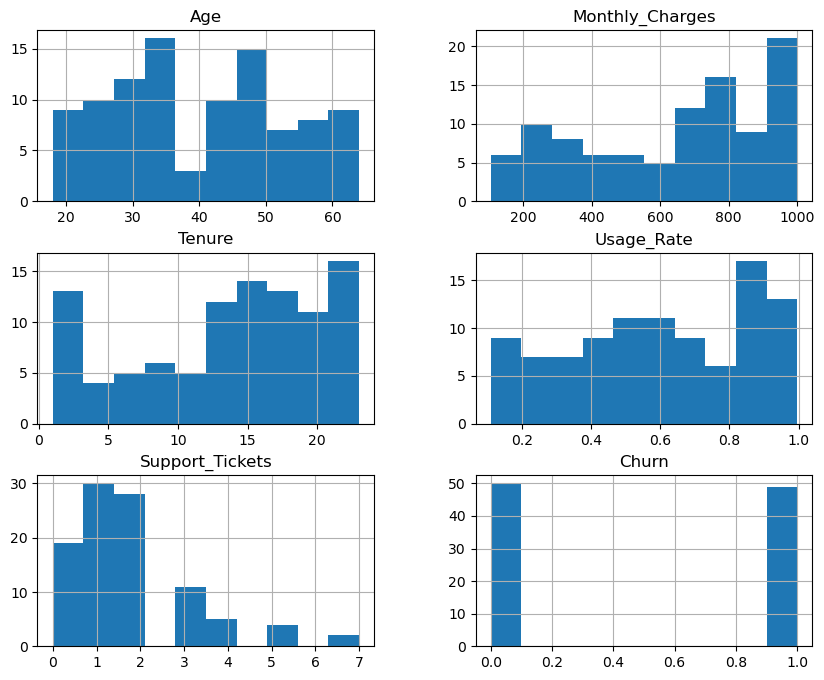

In [10]:
# Histograms
df.hist(figsize=(10, 8))
plt.show()

The distributions show variability across the variables. Some features, such as Monthly_Charges, present a wider spread of values, while Usage_Rate is naturally bounded between 0 and 1. 

The differences in scale reinforce the need for feature scaling before applying clustering algorithms.

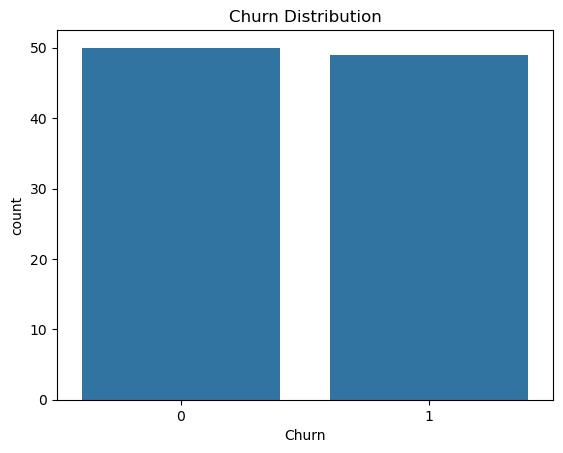

In [11]:
# Analyze churn distribution (used later to evaluate clusters)
sns.countplot(x = 'Churn', data = df)
plt.title('Churn Distribution')
plt.show()

### Outlier Detection

Outliers are identified using both visual inspection (boxplot) and the Interquartile Range (IQR) method.

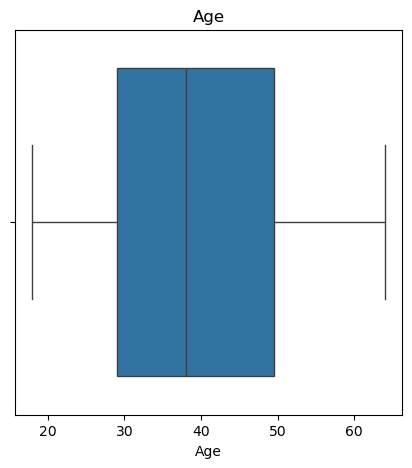

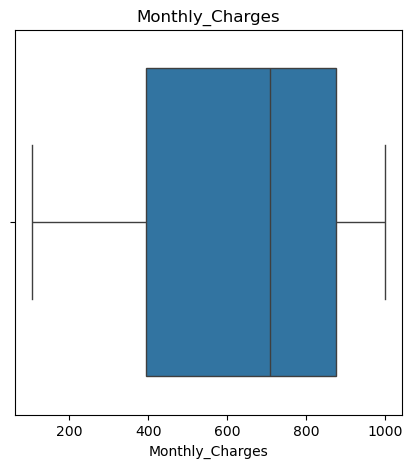

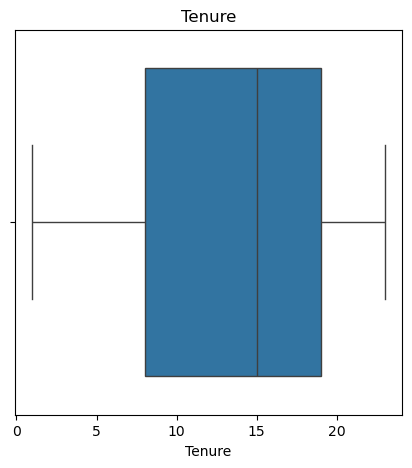

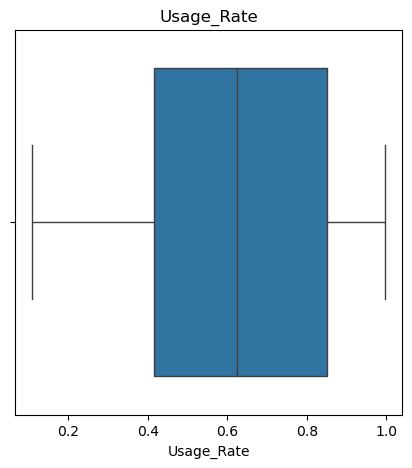

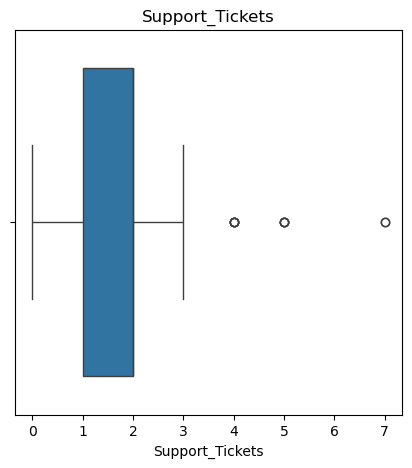

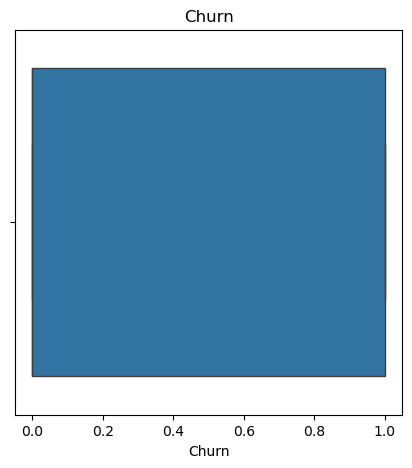

In [12]:
# Visualizing outliers for each variable in the DataFrame
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        plt.figure(figsize = (5, 5))
        sns.boxplot(x = df[column])
        plt.title(column)
        plt.show()

The boxplot indicate the presece of potential outliers in the variable **Support_Tickets**.

In [13]:
# IQR methos
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

Age                 20.500000
Monthly_Charges    480.817001
Tenure              11.000000
Usage_Rate           0.434911
Support_Tickets      1.000000
Churn                1.000000
dtype: float64


In [14]:
# Identify potential outliers using the IQR method
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis = 1)

df_outliers = df[outliers]
df_outliers

,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets,Churn
12,46,743.034018,16,0.697133,5,0
52,41,595.076602,14,0.512320,4,1
53,48,550.847824,12,0.619646,7,1
54,43,667.040379,13,0.630056,5,0
63,34,694.989179,17,0.536049,7,1
79,59,805.273395,21,0.887495,4,1
80,45,875.292673,23,0.980832,4,1
87,52,968.423785,19,0.989904,4,1
89,56,893.738632,23,0.985318,4,1
95,53,999.943535,23,0.865750,5,1


Potential outliers were identified using the Interquartile Range (IQR) method.

Given the small dataset size, extreme observations will be inspected but not necessarily removed to avoid losing valuable information.

### Correlation Analysis

Correlation analysis helps identify relationships between variables and detect potential multicollinearity.

In [15]:
# Calculating the correlation matrix
correlation_matrix = df.corr()
correlation_matrix

,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets,Churn
Age,1.000000,0.856041,0.814066,0.846363,0.431047,0.624298
Monthly_Charges,0.856041,1.000000,0.914275,0.912730,0.378802,0.651229
Tenure,0.814066,0.914275,1.000000,0.891799,0.427516,0.687107
Usage_Rate,0.846363,0.912730,0.891799,1.000000,0.380526,0.643879
Support_Tickets,0.431047,0.378802,0.427516,0.380526,1.000000,0.278220
Churn,0.624298,0.651229,0.687107,0.643879,0.278220,1.000000


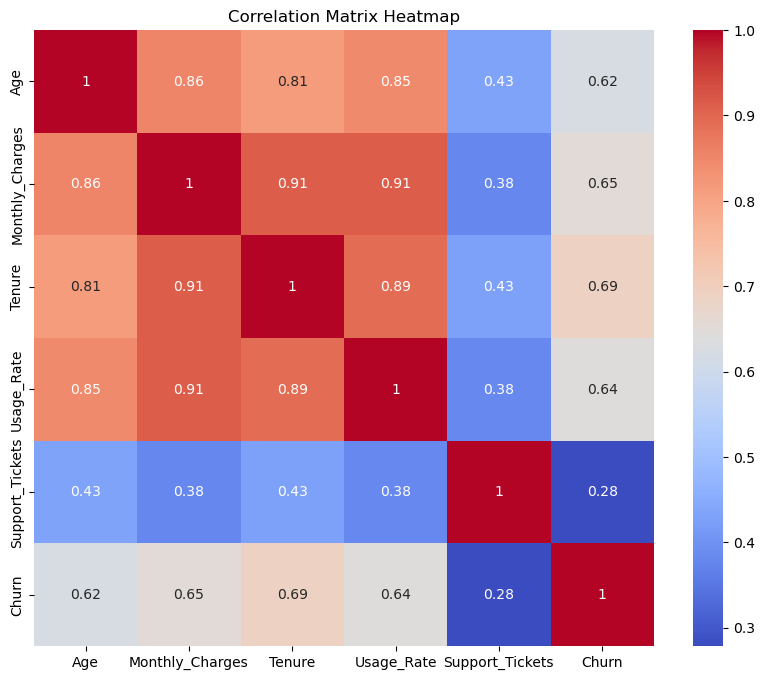

In [16]:
# Plot Heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

#### Correlations Analysis

The correlation matrix shows strong positive relationship between several variables.
- **Monthly_Charges, Tenure and Usage_Rate** show strong correlations, suggesting that customers who stay longer tend to use the service more and pay higher monthly charges.
- **Age** also appears moderately correlated with these behavioral variables.
- **Support_Tickets** shows weaker correlations with other variables, indicating it may represent a different aspect of customer behavior.

Although the dataset contains th variable **Churn**, it will not be used for clustering because the goal of this project is to perform **unsupervised segmentation**. However, it may be used later to analyze churn distribution across the identified clusters.

### Feature Relationship

A pairplot is used to visualize relationships between variables and explore potential patterns in the dataset.

Although **Churn** is not used in the clustering model, it is included here to help identify behavioral differences between customers.

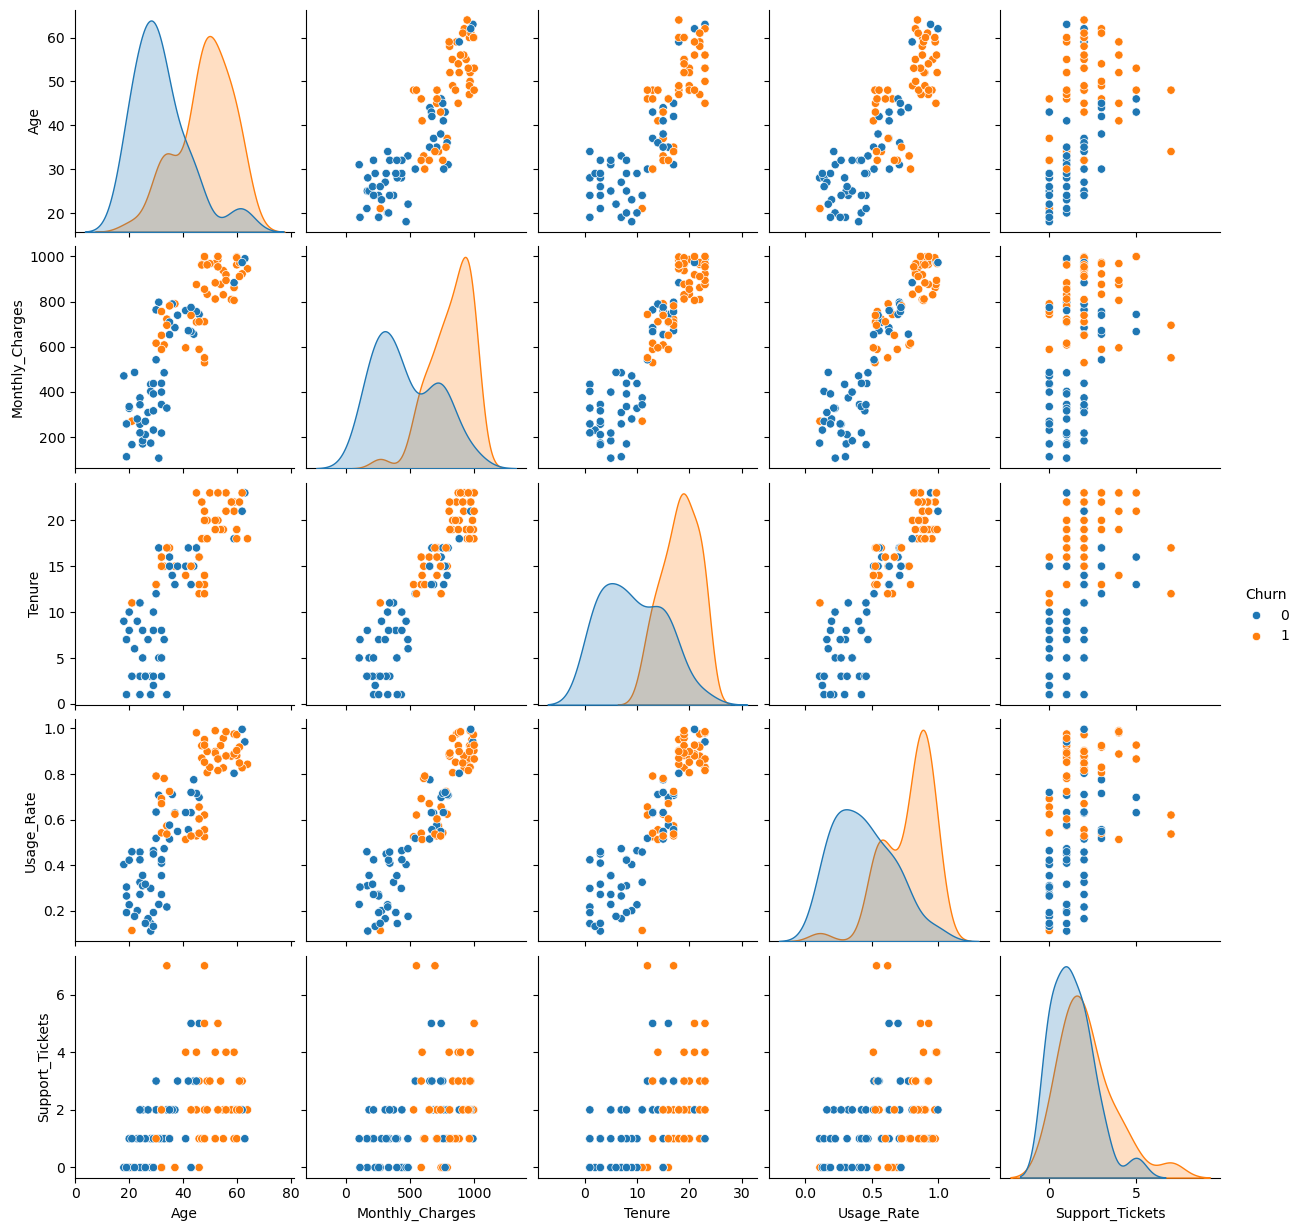

In [17]:
sns.pairplot(df,
             hue = 'Churn', 
             diag_kind = 'kde')
plt.show()

The pairplot reveals relationships between key variables such as Monthly_Charges, Tenure, and Usage_Rate. 

Although no clear separation between groups is immediately visible, some patterns suggest that customers with higher tenure and usage tend to have higher monthly charges.

The inclusion of Churn highlights potential behavioral differences, which will be further explored after clustering.

## Data Preprocessing

In this step, relevant features are selected and the data is scaled to prepare it for clustering. Since K-Means relies on distance calculations, scaling is necessary to ensure that all variables contribute equally to the model.

### Feature Selection

In this step, relevant features are selected for clustering. Variables that represent customer behavior and characteristics are kept, while variables that could bias the segmentation are excluded.

In [18]:
# Remove target variable ('Churn')
features = df.drop(columns=['Churn'])

# Check selected features
features.head()

,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets
0,48,529.152948,13,0.524262,2
1,37,684.502168,13,0.628494,2
2,31,797.016155,17,0.706550,1
3,30,542.025205,12,0.517458,3
4,44,655.498896,15,0.774564,3


- All selected features are numerical and suitable for distance-based clustering methods.
- As showed in the heatmap plot, some features show strong carrelations, horwever, all variables are retained to preserve information about customer behavior. Feature scalling will be applied to mitigate the impact of different magnitudes.

### Feature Scaling

Since the variables have different scales, feature scaling is applied to standardize the data. This step is essential for k-Means, as the algorithm relies on distance calculations and can be influenced by variables with larger magnitudes.

In [19]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
features_scaled = scaler.fit_transform(features)

# Convert back to DataFrame (important for readability)
features_scaled = pd.DataFrame(features_scaled, columns = features.columns)

In [20]:
features_scaled.head()

,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets
0,0.622801,-0.408241,-0.098451,-0.305201,0.170689
1,-0.221820,0.168733,-0.098451,0.091893,0.170689
2,-0.682522,0.586616,0.510712,0.389261,-0.505240
3,-0.759306,-0.360433,-0.250741,-0.331122,0.846619
4,0.315666,0.061014,0.206131,0.648375,0.846619


- StandardScaler was chosen because it centers the data around zero and is commonly used in distance-based algorithms such as K-Means.
- After scaling, all features have a mean close to 0 and a standard deviation close to 1, confirming that the data has been properly standardized.

## Clusterting Model (K-Means)

In this step, the K-Means algorithm is applied to segment customers into distinct groups based on their characteristics.

To determine the optimal number of clusters, both the Elbow Method and the Silhouette Score are used.

### Elbow Method

  File "C:\Users\aleva\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\aleva\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aleva\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aleva\anaconda3\Lib\subprocess.

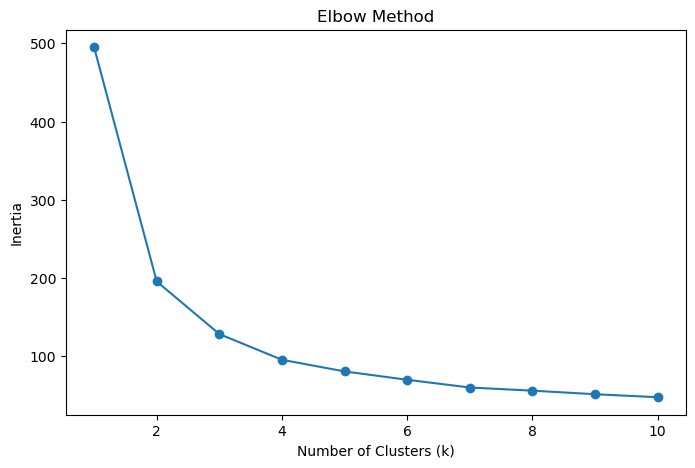

In [21]:
inertia = []
k_range = range(1, 11)

for k in  k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize = (8,5))
plt.plot(k_range, inertia, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The Elbow Method shows how inertia decreases as the number of clusters increases.

The optimal number of clusters is typically identified as the 'elbow point', where the rate of decrease sharply changes.

### Silhouette Score

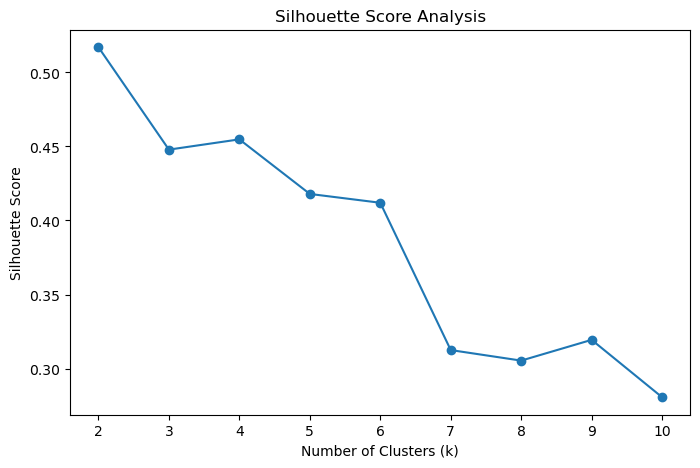

In [22]:
silhouette_scores = []

k_range = range(2, 11)

for k in k_range:
    if k == 1:
        continue
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    silhouette_scores.append(score)

# Plot
plt.figure(figsize = (8,5))
plt.plot(k_range, silhouette_scores, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')
plt.show()

The Silhouette Score measures how well-separated the clusters are.

Higher values indicate better-defined and more distinct clusters.

### Model Comparison

Although the Elbow Method and Silhouette Score provide guidance for selecting the number of clusters, the optimal value of k is not always clear.

To ensure a robust decision, models with **k=3 and k=4** are evaluated and compared based on clustering performance, visual separation, and business interpretability.

### Silhouette Score Comparison

In [23]:
for k in [3, 4]:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)

    print(f"k = {k} | Silhouette Score = {score:.4f}")

k = 3 | Silhouette Score = 0.4479
k = 4 | Silhouette Score = 0.4548


The Silhouette Score results show that both models achieve similar peformance, with **k = 4 slightly outperforming k = 3**.

However, the difference between the scores is relatively small, indicating that both configurations provide comparable cluster separation.

### Cluster Visualization Comparison

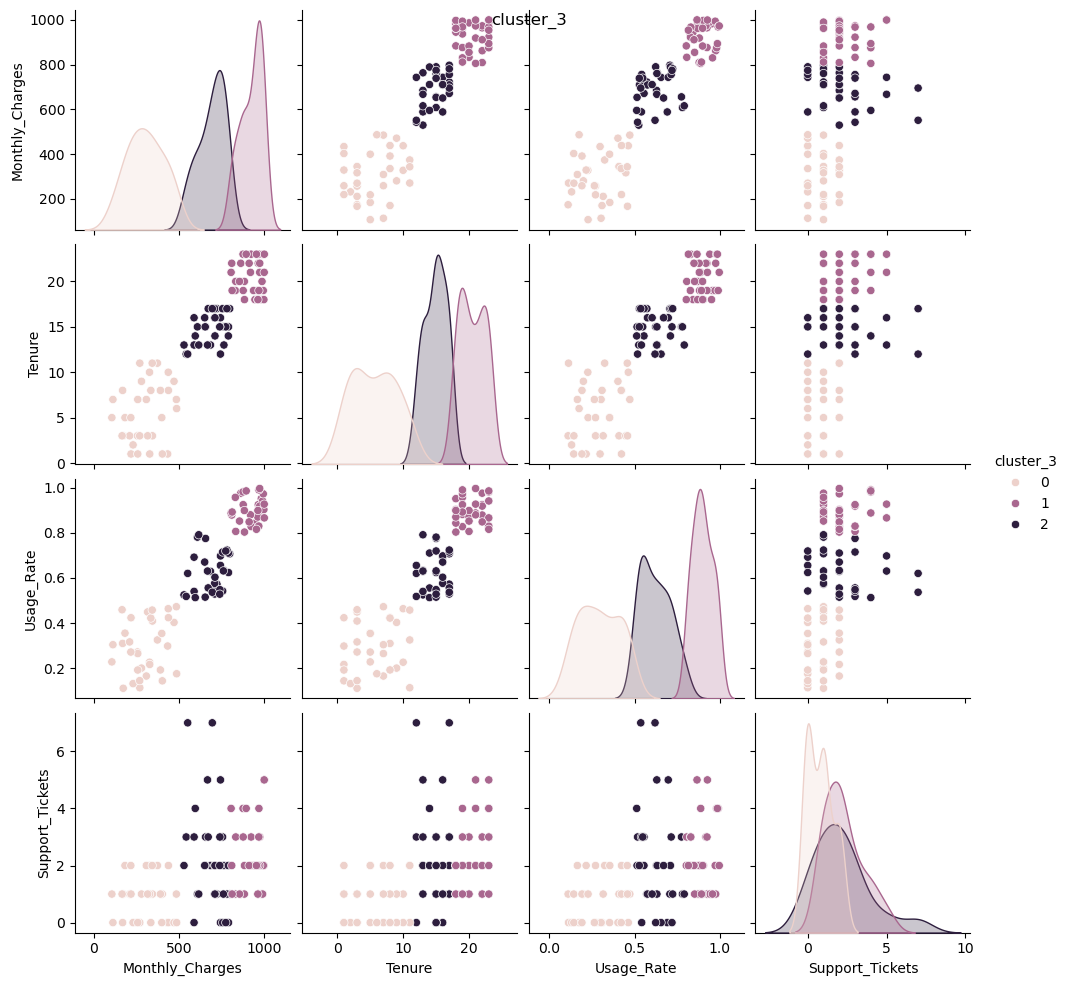

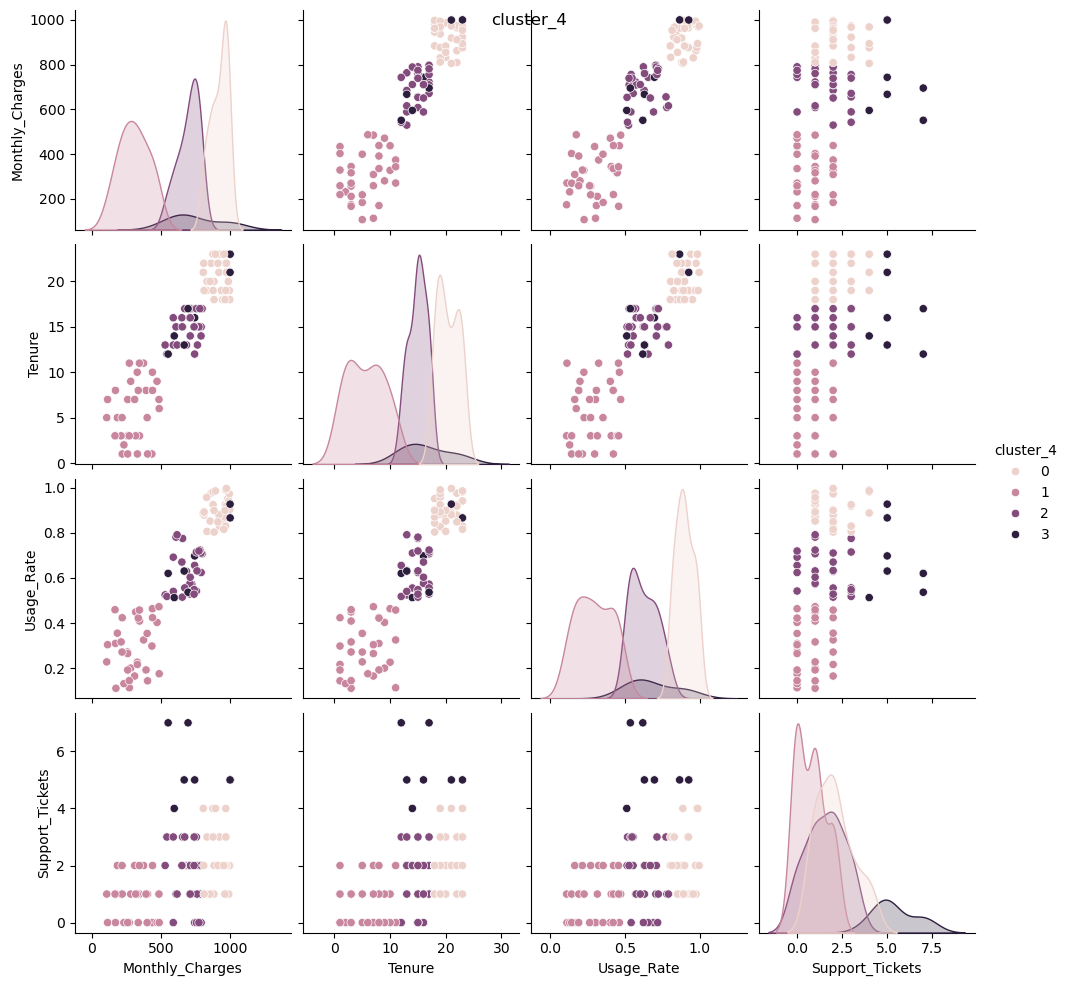

In [24]:
for k in [3, 4]:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    df[f'cluster_{k}'] = kmeans.fit_predict(features_scaled)

    sns.pairplot(df,
                 vars = ['Monthly_Charges', 'Tenure', 'Usage_Rate', 'Support_Tickets'],
                 hue = f'cluster_{k}')
    plt.suptitle(f'cluster_{k}')
    plt.show()

The visual inspection of the clusters reveals that, although k = 4, provides a slightly higher Silhouette Score, some overlap between clusters is observed.

In contrast, k = 3 shows a clearer separation between groups, with more distinct and well-distributed clusters across the feature space.

### Cluster Profiling Comparison

In [25]:
profiles_list = []

for k in [3, 4]:
    temp = df.groupby(f'cluster_{k}').mean().copy()
    temp['k'] = k
    temp['cluster'] = temp.index
    profiles_list.append(temp)

profiles_df = pd.concat(profiles_list).reset_index(drop=True)

profiles_df = profiles_df[['k', 'cluster'] + [col for col in df.columns if col not in ['cluster_3', 'cluster_4']]]
profiles_df.round(2)

,k,cluster,Age,Monthly_Charges,Tenure,Usage_Rate,Support_Tickets,Churn
0,3,0,25.85,302.86,5.61,0.29,0.79,0.03
1,3,1,54.85,923.90,20.48,0.90,2.27,0.91
2,3,2,38.97,690.45,14.85,0.62,2.18,0.55
3,4,0,55.13,919.01,20.39,0.90,2.10,0.90
4,4,1,25.85,302.86,5.61,0.29,0.79,0.03
5,4,2,38.36,697.64,14.93,0.63,1.57,0.54
6,4,3,44.71,750.04,16.57,0.68,5.43,0.71


Cluster profiling indicates that both models identify meaningful segments. 

However, k=3 provides clearer and more interpretable clusters, while k=4 introduces additional complexity without significant improvement.

Therefore, k=3 is selected as the final model.

## Cluster Interpretation

The K-Means clustering model identified three distinct customer segments based on behavioral and usage patterns:

- **Cluster 0 - Low Engagement Customers**
  Customers with low monthly charges, low usage rates, and short tenure.

- **Cluster 1 - High-Value At-Risk Customers**
  Customers with high monthly charges, high usage, and long tenure.

- **Cluster 2 - Moderate Customers**
  Customers with intermediate characteristics across all variables. This group represents a stable and balanced customer base.

### Churn Analysis

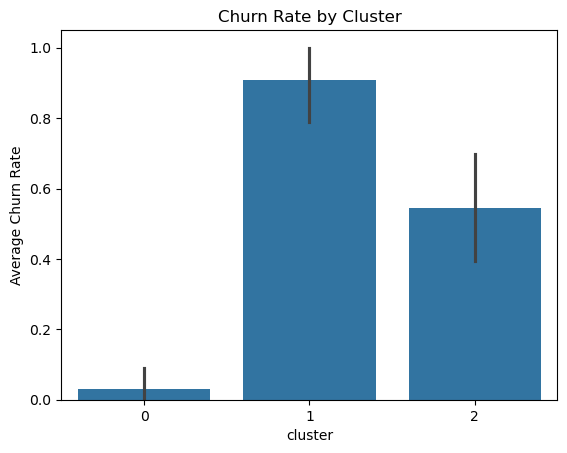

In [26]:
# Final model
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
df['cluster'] = kmeans.fit_predict(features_scaled)

# Plot
sns.barplot(x = 'cluster', y = 'Churn', data = df)
plt.title('Churn Rate by Cluster')
plt.ylabel('Average Churn Rate')
plt.show()

The analysis of churn across clusters reveals significant differences in customer behavior. 

Cluster 1 shows the highest churn rate by a considerable margin, confirming that high-value customers are also the most at risk of leaving.

In contrast, Cluster 0 presents very low churn, while Cluster 2 remains at a moderate level.

## Business Insights

The segmentation analysis provides actionable insights for strategic decision-making:

- **Cluster 1 (High-Value At-Risk Customers)**
  This segment represents the most critical business opportunity. These customer generate high revenue but are also the most likely to churn.
   → *Recommended action*: Implement targeted retention strategies, such as personalized offers, loyalty programs, or proactive customer support.

- **Cluster 0 (Low Engagement Customers)**
  These customers show low usage and low value, but also low churn risk.
   → *Recommended action*: Develop engagement strategies to increase usage, such as onboarding improvements, feature promotion, or incentives.

- **Cluster 2 (Moderate Customers)**
   This group represents a stable customer base with moderate value.
    → *Recommended action*: Focus on upselling ans cross-selling opportunities to graduallu increase customer value.

## Executive Summary

This project applied unsupervised learning techniques to segment customers based on behavioral data.

Three distinct customer segments were identified, revealing important differences in value and churn risks.

The analysis highlighted a critical segment of high-value customers with elevated churn risk, representing a key opportunity for targeted retention strategies.

Overall, the segmentation provides a data-driven foundation to support marketing decisions, improve customer retention, and maximize business value.